HOUSE PRICE DATASET — INSPECTION

Shape    : (2000, 10)
Columns  : ['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage', 'Price']

First 5 rows:
   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  

Data types & nulls:
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         2000 non-null   int64
 1   Area

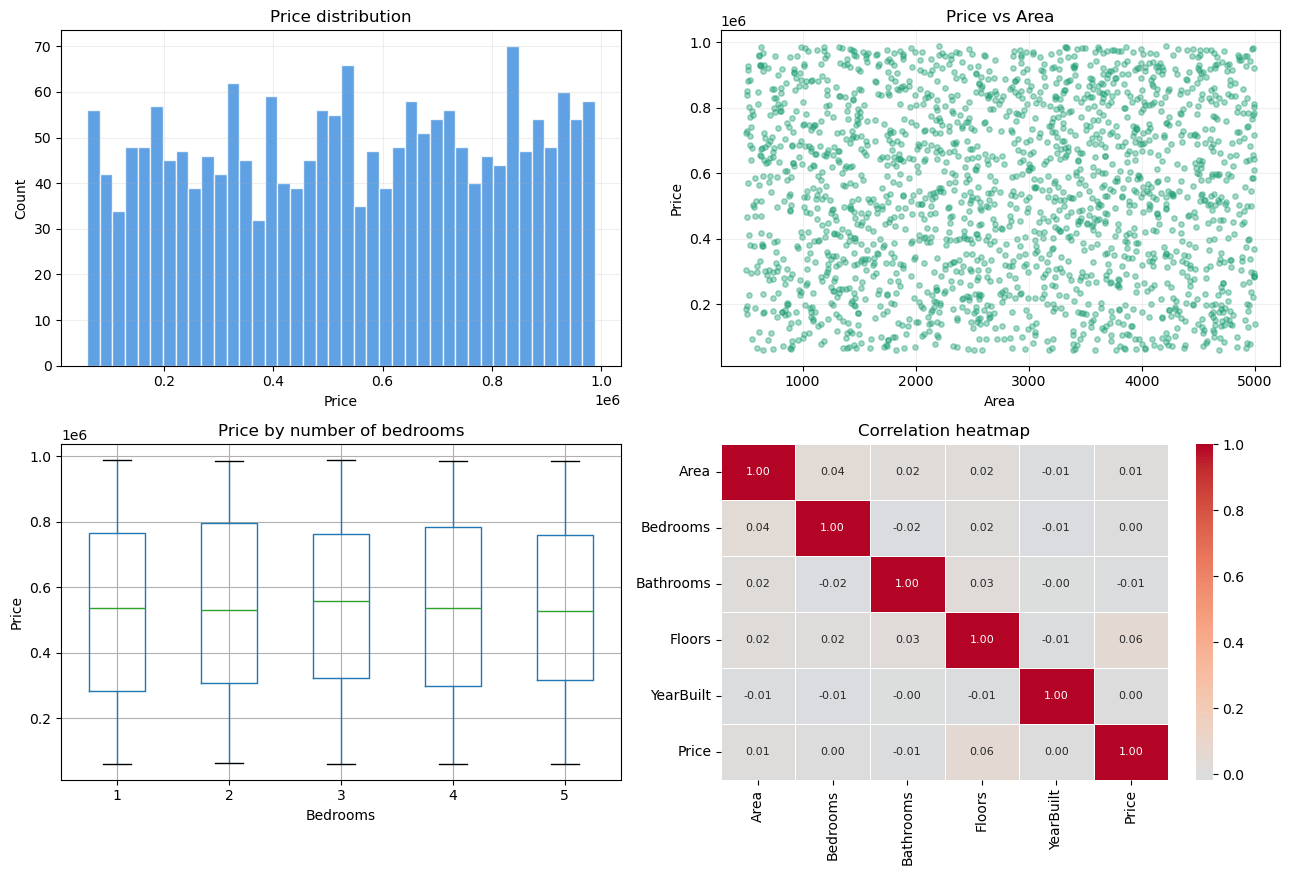


[Saved] task6_eda.png

Training samples : 1568
Test samples     : 392

MODEL PERFORMANCE ON TEST SET

Linear Regression
  MAE  : 224,113.41
  RMSE : 264,682.61
  R²   : 0.0043

Gradient Boosting
  MAE  : 232,998.02
  RMSE : 275,185.39
  R²   : -0.0762


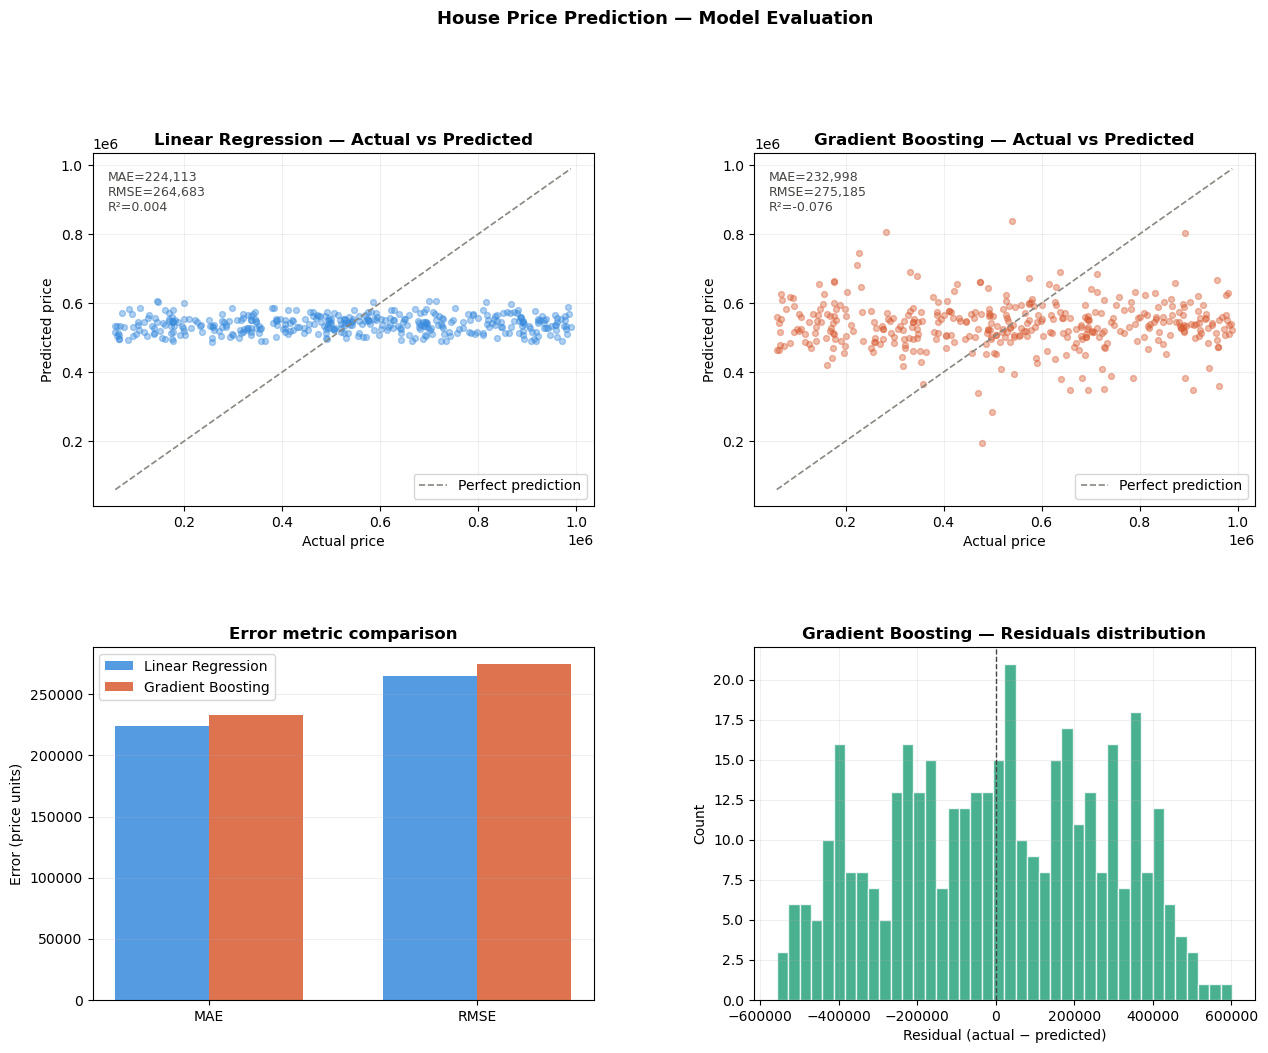


[Saved] task6_model_results.png


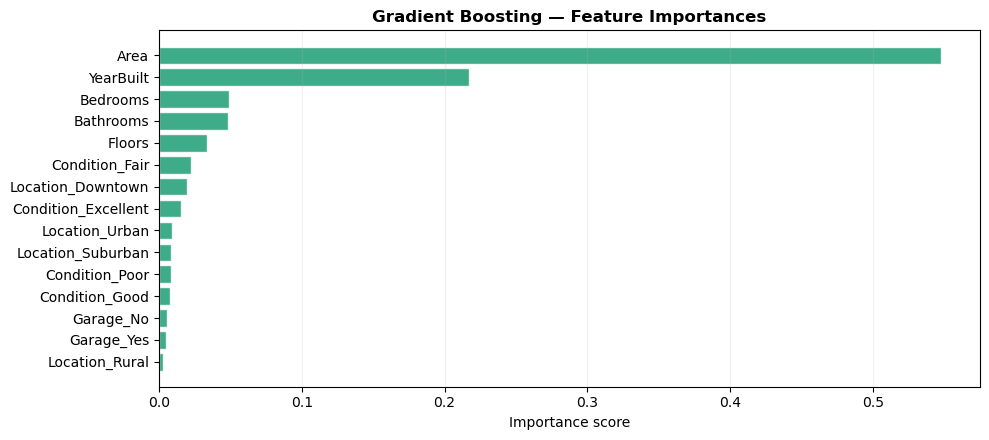

[Saved] task6_feature_importance.png

SUMMARY
  Linear Regression  — MAE: 224,113  RMSE: 264,683  R²: 0.004
  Gradient Boosting  — MAE: 232,998  RMSE: 275,185  R²: -0.076

✓ Task 6 complete.


In [2]:
"""
Task 6: House Price Prediction


Dataset : House Price Prediction Dataset (Kaggle)
Models  : Linear Regression, Gradient Boosting Regressor
Metrics : MAE, RMSE, R²
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ─────────────────────────────────────────────
# 1. LOAD DATASET
# ─────────────────────────────────────────────
df = pd.read_csv("House Price Prediction Dataset.csv")

print("=" * 55)
print("HOUSE PRICE DATASET — INSPECTION")
print("=" * 55)
print(f"\nShape    : {df.shape}")
print(f"Columns  : {list(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nData types & nulls:")
print(df.info())
print(f"\nSummary statistics:")
print(df.describe())

# ─────────────────────────────────────────────
# 2. IDENTIFY COLUMNS
# ─────────────────────────────────────────────
# Matched to this dataset's actual columns:
# ['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
#  'Location', 'Condition', 'Garage', 'Price']
TARGET = "Price"

# Numeric features (square footage, bedrooms, bathrooms, etc.)
NUMERIC_FEATURES = [c for c in [
    "Area", "Bedrooms", "Bathrooms", "Floors", "YearBuilt"
] if c in df.columns]

# Categorical features (location, condition, garage, etc.)
CATEGORICAL_FEATURES = [c for c in [
    "Location", "Condition", "Garage"
] if c in df.columns]

# 'Id' is dropped — it's just a row identifier, not a predictive feature

print(f"\nTarget               : {TARGET}")
print(f"Numeric features      : {NUMERIC_FEATURES}")
print(f"Categorical features   : {CATEGORICAL_FEATURES}")

# ─────────────────────────────────────────────
# 3. DATA CLEANING / PREPROCESSING
# ─────────────────────────────────────────────
print("\n--- Missing values before cleaning ---")
print(df.isnull().sum())

# Drop rows with a missing target (can't train/evaluate without it)
df.dropna(subset=[TARGET], inplace=True)

# Fill missing numeric values with median, categorical with mode
for col in NUMERIC_FEATURES:
    df[col].fillna(df[col].median(), inplace=True)
for col in CATEGORICAL_FEATURES:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Remove duplicate rows
before = len(df)
df.drop_duplicates(inplace=True)
print(f"\nRemoved {before - len(df)} duplicate rows.")

# Remove extreme price outliers (top/bottom 1%) — common for real estate data
low, high = df[TARGET].quantile([0.01, 0.99])
df = df[(df[TARGET] >= low) & (df[TARGET] <= high)]
print(f"Filtered to price range: {low:.0f} – {high:.0f}")
print(f"Final shape after cleaning: {df.shape}")

# ─────────────────────────────────────────────
# 4. EXPLORATORY DATA ANALYSIS
# ─────────────────────────────────────────────
fig_eda, axes = plt.subplots(2, 2, figsize=(13, 9))
fig_eda.suptitle("EDA — House Price Dataset", fontsize=14, fontweight="bold")

# Price distribution
axes[0,0].hist(df[TARGET], bins=40, color="#378ADD", alpha=0.8, edgecolor="white")
axes[0,0].set_title("Price distribution")
axes[0,0].set_xlabel("Price"); axes[0,0].set_ylabel("Count")
axes[0,0].grid(alpha=0.2)

# Price vs primary size feature
size_col = "Area"
axes[0,1].scatter(df[size_col], df[TARGET], alpha=0.4, color="#1D9E75", s=15)
axes[0,1].set_title(f"Price vs {size_col}")
axes[0,1].set_xlabel(size_col); axes[0,1].set_ylabel("Price")
axes[0,1].grid(alpha=0.2)

# Price by bedrooms
if "Bedrooms" in df.columns:
    df.boxplot(column=TARGET, by="Bedrooms", ax=axes[1,0])
    axes[1,0].set_title("Price by number of bedrooms")
    axes[1,0].set_xlabel("Bedrooms"); axes[1,0].set_ylabel("Price")
    plt.suptitle("")  # remove auto-generated subtitle from boxplot
else:
    axes[1,0].axis("off")

# Correlation heatmap (numeric features only)
corr_cols = NUMERIC_FEATURES + [TARGET]
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, linecolor="white", ax=axes[1,1],
            annot_kws={"size": 8})
axes[1,1].set_title("Correlation heatmap")

plt.tight_layout()
plt.savefig("task6_eda.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n[Saved] task6_eda.png")

# ─────────────────────────────────────────────
# 5. FEATURE / TARGET SPLIT
# ─────────────────────────────────────────────
X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"\nTraining samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

# ─────────────────────────────────────────────
# 6. PREPROCESSING PIPELINE
# ─────────────────────────────────────────────
# Numeric features  -> scaled
# Categorical features -> one-hot encoded
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), NUMERIC_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
])

# ─────────────────────────────────────────────
# 7. BUILD & TRAIN MODELS
# ─────────────────────────────────────────────
lr_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])
lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)

gb_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42
    ))
])
gb_pipeline.fit(X_train, y_train)
gb_pred = gb_pipeline.predict(X_test)

# ─────────────────────────────────────────────
# 8. EVALUATE
# ─────────────────────────────────────────────
def evaluate(name, actual, predicted):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2   = r2_score(actual, predicted)
    print(f"\n{name}")
    print(f"  MAE  : {mae:,.2f}")
    print(f"  RMSE : {rmse:,.2f}")
    print(f"  R²   : {r2:.4f}")
    return mae, rmse, r2

print("\n" + "=" * 45)
print("MODEL PERFORMANCE ON TEST SET")
print("=" * 45)
lr_mae, lr_rmse, lr_r2 = evaluate("Linear Regression", y_test, lr_pred)
gb_mae, gb_rmse, gb_r2 = evaluate("Gradient Boosting", y_test, gb_pred)

# ─────────────────────────────────────────────
# 9. VISUALISE: ACTUAL vs PREDICTED
# ─────────────────────────────────────────────
fig2 = plt.figure(figsize=(15, 11))
gs   = gridspec.GridSpec(2, 2, figure=fig2, hspace=0.4, wspace=0.32)

# 9a. Actual vs Predicted — Linear Regression
ax1 = fig2.add_subplot(gs[0, 0])
ax1.scatter(y_test, lr_pred, alpha=0.4, color="#378ADD", s=18)
lims = [min(y_test.min(), lr_pred.min()), max(y_test.max(), lr_pred.max())]
ax1.plot(lims, lims, color="#888780", linestyle="--", linewidth=1.2, label="Perfect prediction")
ax1.set_title("Linear Regression — Actual vs Predicted", fontweight="bold")
ax1.set_xlabel("Actual price"); ax1.set_ylabel("Predicted price")
ax1.legend(); ax1.grid(alpha=0.2)
ax1.text(0.03, 0.95, f"MAE={lr_mae:,.0f}\nRMSE={lr_rmse:,.0f}\nR²={lr_r2:.3f}",
         transform=ax1.transAxes, fontsize=9, color="#444441", verticalalignment="top")

# 9b. Actual vs Predicted — Gradient Boosting
ax2 = fig2.add_subplot(gs[0, 1])
ax2.scatter(y_test, gb_pred, alpha=0.4, color="#D85A30", s=18)
lims2 = [min(y_test.min(), gb_pred.min()), max(y_test.max(), gb_pred.max())]
ax2.plot(lims2, lims2, color="#888780", linestyle="--", linewidth=1.2, label="Perfect prediction")
ax2.set_title("Gradient Boosting — Actual vs Predicted", fontweight="bold")
ax2.set_xlabel("Actual price"); ax2.set_ylabel("Predicted price")
ax2.legend(); ax2.grid(alpha=0.2)
ax2.text(0.03, 0.95, f"MAE={gb_mae:,.0f}\nRMSE={gb_rmse:,.0f}\nR²={gb_r2:.3f}",
         transform=ax2.transAxes, fontsize=9, color="#444441", verticalalignment="top")

# 9c. Error metric comparison
ax3 = fig2.add_subplot(gs[1, 0])
metric_names = ["MAE", "RMSE"]
x = np.arange(len(metric_names))
w = 0.35
ax3.bar(x - w/2, [lr_mae, lr_rmse], w, label="Linear Regression", color="#378ADD", alpha=0.85)
ax3.bar(x + w/2, [gb_mae, gb_rmse], w, label="Gradient Boosting", color="#D85A30", alpha=0.85)
ax3.set_xticks(x); ax3.set_xticklabels(metric_names)
ax3.set_ylabel("Error (price units)")
ax3.set_title("Error metric comparison", fontweight="bold")
ax3.legend(); ax3.grid(axis="y", alpha=0.2)

# 9d. Residuals distribution (Gradient Boosting)
ax4 = fig2.add_subplot(gs[1, 1])
residuals = y_test - gb_pred
ax4.hist(residuals, bins=40, color="#1D9E75", alpha=0.8, edgecolor="white")
ax4.axvline(0, color="#444441", linestyle="--", linewidth=1)
ax4.set_title("Gradient Boosting — Residuals distribution", fontweight="bold")
ax4.set_xlabel("Residual (actual − predicted)"); ax4.set_ylabel("Count")
ax4.grid(alpha=0.2)

plt.suptitle("House Price Prediction — Model Evaluation", fontsize=13, fontweight="bold", y=1.01)
plt.savefig("task6_model_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n[Saved] task6_model_results.png")

# ─────────────────────────────────────────────
# 10. FEATURE IMPORTANCE (Gradient Boosting)
# ─────────────────────────────────────────────
feature_names = (
    NUMERIC_FEATURES +
    list(gb_pipeline.named_steps["preprocess"]
         .named_transformers_["cat"]
         .get_feature_names_out(CATEGORICAL_FEATURES))
)
importances = gb_pipeline.named_steps["model"].feature_importances_

fig3, ax = plt.subplots(figsize=(10, max(4, len(feature_names) * 0.3)))
sorted_idx = np.argsort(importances)
ax.barh([feature_names[i] for i in sorted_idx],
        importances[sorted_idx], color="#1D9E75", alpha=0.85, edgecolor="white")
ax.set_title("Gradient Boosting — Feature Importances", fontweight="bold")
ax.set_xlabel("Importance score")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.savefig("task6_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("[Saved] task6_feature_importance.png")

# ─────────────────────────────────────────────
# 11. SUMMARY
# ─────────────────────────────────────────────
print("\n" + "=" * 55)
print("SUMMARY")
print("=" * 55)
print(f"  Linear Regression  — MAE: {lr_mae:,.0f}  RMSE: {lr_rmse:,.0f}  R²: {lr_r2:.3f}")
print(f"  Gradient Boosting  — MAE: {gb_mae:,.0f}  RMSE: {gb_rmse:,.0f}  R²: {gb_r2:.3f}")

